<a href="https://colab.research.google.com/github/HeaDShoT4iK/AsilbekKI/blob/main/11-amaliyot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Activation Function Comparison on MNIST

This notebook demonstrates how to compare the performance of three common activation functions (Sigmoid, ReLU, and Tanh) in a simple neural network trained on the MNIST handwritten digits dataset. We will:

1.  Load and preprocess the MNIST dataset.
2.  Define a neural network architecture.
3.  Train three separate models, each using a different activation function.
4.  Visualize the training and validation accuracy/loss.
5.  Compare the final test performance of each model.

In [1]:
# Cell 1: Setup and Data Loading
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print(f"TensorFlow Version: {tf.__version__}")

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize the images to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape images to (num_samples, 784) for a dense network
x_train = x_train.reshape((-1, 28 * 28))
x_test = x_test.reshape((-1, 28 * 28))

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

TensorFlow Version: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 784)
y_train shape: (60000,)
x_test shape: (10000, 784)
y_test shape: (10000,)


### Model Definition

We define a function to create a `Sequential` model with the specified architecture: an Input layer, two Dense hidden layers with 128 and 64 neurons respectively, and an Output layer with 10 neurons (for 10 digit classes) using a `softmax` activation.

In [3]:
# Cell 2: Model Definition Function
def create_model(activation_function):
    model = keras.Sequential([
        keras.Input(shape=(784,)),
        layers.Dense(128, activation=activation_function, name=f"hidden_1_{activation_function}"),
        layers.Dense(64, activation=activation_function, name=f"hidden_2_{activation_function}"),
        layers.Dense(10, activation="softmax", name="output_layer")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("Model creation function defined.")

Model creation function defined.


### Training Models

Now, we'll create and train three separate models, each using a different activation function: Sigmoid, ReLU, and Tanh. Each model will be trained for 5 epochs, and its training history will be saved.

In [4]:
# Cell 3: Model Creation and Training (Sigmoid)
print("\n--- Training Sigmoid Model ---")
sigmoid_model = create_model("sigmoid")
sigmoid_history = sigmoid_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    verbose=0 # Suppress verbose output to keep console clean
)
print("Sigmoid model trained.")


--- Training Sigmoid Model ---
Sigmoid model trained.


In [5]:
# Cell 4: Model Creation and Training (ReLU)
print("\n--- Training ReLU Model ---")
relu_model = create_model("relu")
relu_history = relu_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)
print("ReLU model trained.")


--- Training ReLU Model ---
ReLU model trained.


In [6]:
# Cell 5: Model Creation and Training (Tanh)
print("\n--- Training Tanh Model ---")
tanh_model = create_model("tanh")
tanh_history = tanh_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)
print("Tanh model trained.")


--- Training Tanh Model ---
Tanh model trained.


### Plotting Training History

We will now plot the training and validation accuracy and loss for all three models over the 5 epochs. This will help visualize how each activation function affects the learning process.

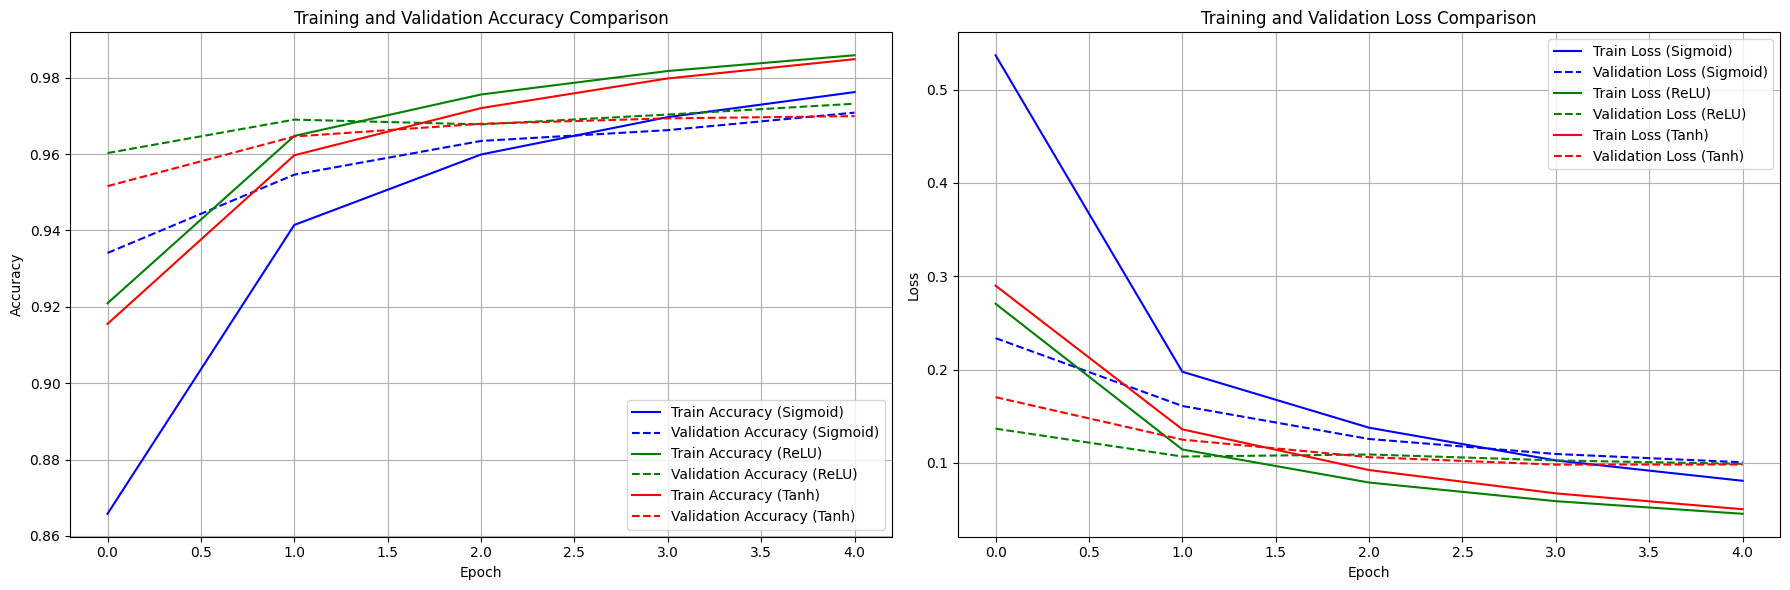

In [7]:
# Cell 6: Plotting Training vs Validation Accuracy and Loss
def plot_history(history, activation_name, ax, metric='accuracy'):
    ax.plot(history.history[metric], label=f'Train {metric} ({activation_name})')
    ax.plot(history.history[f'val_{metric}'], label=f'Validation {metric} ({activation_name})')
    ax.set_title(f'Training vs. Validation {metric.capitalize()} for {activation_name} Activation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.capitalize())
    ax.legend()
    ax.grid(True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot Accuracy
ax1.plot(sigmoid_history.history['accuracy'], label='Train Accuracy (Sigmoid)', color='blue', linestyle='-')
ax1.plot(sigmoid_history.history['val_accuracy'], label='Validation Accuracy (Sigmoid)', color='blue', linestyle='--')

ax1.plot(relu_history.history['accuracy'], label='Train Accuracy (ReLU)', color='green', linestyle='-')
ax1.plot(relu_history.history['val_accuracy'], label='Validation Accuracy (ReLU)', color='green', linestyle='--')

ax1.plot(tanh_history.history['accuracy'], label='Train Accuracy (Tanh)', color='red', linestyle='-')
ax1.plot(tanh_history.history['val_accuracy'], label='Validation Accuracy (Tanh)', color='red', linestyle='--')

ax1.set_title('Training and Validation Accuracy Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot Loss
ax2.plot(sigmoid_history.history['loss'], label='Train Loss (Sigmoid)', color='blue', linestyle='-')
ax2.plot(sigmoid_history.history['val_loss'], label='Validation Loss (Sigmoid)', color='blue', linestyle='--')

ax2.plot(relu_history.history['loss'], label='Train Loss (ReLU)', color='green', linestyle='-')
ax2.plot(relu_history.history['val_loss'], label='Validation Loss (ReLU)', color='green', linestyle='--')

ax2.plot(tanh_history.history['loss'], label='Train Loss (Tanh)', color='red', linestyle='-')
ax2.plot(tanh_history.history['val_loss'], label='Validation Loss (Tanh)', color='red', linestyle='--')

ax2.set_title('Training and Validation Loss Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Final Comparison Table

Finally, we evaluate each model on the untouched test dataset and present the results (test accuracy and loss) in a pandas DataFrame for a clear comparison.

In [8]:
# Cell 7: Model Evaluation and Comparison Table

# Evaluate each model on the test set
sigmoid_loss, sigmoid_accuracy = sigmoid_model.evaluate(x_test, y_test, verbose=0)
relu_loss, relu_accuracy = relu_model.evaluate(x_test, y_test, verbose=0)
tanh_loss, tanh_accuracy = tanh_model.evaluate(x_test, y_test, verbose=0)

# Create a pandas DataFrame for comparison
results_df = pd.DataFrame({
    'Activation Function': ['Sigmoid', 'ReLU', 'Tanh'],
    'Test Loss': [sigmoid_loss, relu_loss, tanh_loss],
    'Test Accuracy': [sigmoid_accuracy, relu_accuracy, tanh_accuracy]
})

print("\n--- Comparison of Activation Functions on Test Set ---")
display(results_df)

print("\nComparison complete!")


--- Comparison of Activation Functions on Test Set ---


,Activation Function,Test Loss,Test Accuracy
0,Sigmoid,0.093540,0.9711
1,ReLU,0.090934,0.9736
2,Tanh,0.090961,0.9731



Comparison complete!
